In [114]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import pickle 
import scipy
import time as tim

from neuromancer.psl import plot
from neuromancer import psl
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from neuromancer.system import Node, System
from neuromancer.slim import slim
from neuromancer.trainer import Trainer
from neuromancer.problem import Problem
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer. modules import blocks
import joblib

from sklearn.preprocessing import StandardScaler
torch.manual_seed(0)

## Generate trajectories from ODE system 

In this example we don't assume any prior knowledge on the system dynamics. We will only have access to limited measurements of the system states $x$ of an unknown [ordinary differential equations](https://en.wikipedia.org/wiki/Ordinary_differential_equation) (ODE).

Select the system_name from the available list of [nonautonomous ODE systems](https://github.com/pnnl/neuromancer/blob/master/src/neuromancer/psl/nonautonomous.py):
- TwoTank
- CSTR
- SwingEquation
- IverSimple

# Get and save data - (Already done)

## Create training data of sampled trajectories

We will obtain a dataset of sampled trajectories of the system dynamics in the form of input-state tuples: 
$$D = \big[(u^i_0, \hat{x}^i_0), ..., (u^i_N, \hat{x}^i_{N}) \big], \, \, i \in [1, ..., m]$$
where $N$ represents the prediction horizon, $m$ represents number of measured trajectories, and $i$ represents an index of the sampled trajectory.
Variables $x_k$ represent system states, and $u_k$ are exogenous inputs at time $k$.

In [115]:
# with open('data/train_real.pkl', 'rb') as fp:
#         train_sim = pickle.load(fp)

# with open('data/test_real.pkl', 'rb') as fp:
#         test_sim = pickle.load(fp)

In [116]:
from scipy.io import loadmat

""" #data = loadmat('data.mat')"""


test_data = loadmat('test_data_ident.mat')
train_data = loadmat('train_data_ident.mat')

"""
# Explore the content


print(train_data['Utrain'].shape)
print(train_data['Ytrain'].shape)

print(test_data['Utest'].shape)
print(test_data['Ytest'].shape) """

""" print(test_data['U'].shape)
print(test_data['Y'].shape)
print(test_data['X'].shape)
print(test_data['U'].shape) """
""" 
print(data['U'].shape)
print(data.keys())
print(data['U'].shape) """

" \nprint(data['U'].shape)\nprint(data.keys())\nprint(data['U'].shape) "

In [117]:

def get_data(train_sim, test_sim, nx, nu, nsteps, bs, scaler, scalerU):
    dev_sim = train_sim

    # Combine training and test data for reshaping
    trainY = np.vstack((train_sim['Y'], test_sim['Y']))
    trainU = np.vstack((train_sim['U'], test_sim['U']))#cely dataset

    nsim = trainY.shape[0]
    nbatch = nsim // nsteps
    length = nbatch * nsteps

    trainX = scaler.transform(trainY[:length]).reshape(nbatch, nsteps, nx)
    trainU = scalerU.transform(trainU[:length]).reshape(nbatch, nsteps, nu)

    train_dataset = DictDataset({
        'Y': torch.tensor(trainX, dtype=torch.float32),
        'Y0': torch.tensor(trainX[:, 0:1, :], dtype=torch.float32),
        'U': torch.tensor(trainU, dtype=torch.float32)
    }, name='train')

    train_loader = DataLoader(train_dataset, batch_size=bs,
                              collate_fn=train_dataset.collate_fn, shuffle=True)

    # Dev set
    nsim = dev_sim['Y'].shape[0]
    nbatch = nsim // nsteps
    length = nbatch * nsteps

    devX = scaler.transform(dev_sim['Y'][:length]).reshape(nbatch, nsteps, nx)
    devU = scalerU.transform(dev_sim['U'][:length]).reshape(nbatch, nsteps, nu)

    dev_dataset = DictDataset({
        'Y': torch.tensor(devX, dtype=torch.float32),
        'Y0': torch.tensor(devX[:, 0:1, :], dtype=torch.float32),
        'U': torch.tensor(devU, dtype=torch.float32)
    }, name='dev')

    dev_loader = DataLoader(dev_dataset, batch_size=bs,
                            collate_fn=dev_dataset.collate_fn, shuffle=True)

    # Test set (single trajectory)
    nsim = test_sim['Y'].shape[0]
    nbatch = nsim // nsteps
    length = nbatch * nsteps

    testX = scaler.transform(test_sim['Y'][:length]).reshape(1, nbatch * nsteps, nx)
    testU = scalerU.transform(test_sim['U'][:length]).reshape(1, nbatch * nsteps, nu)

    test_data = {
        'Y': torch.tensor(testX, dtype=torch.float32),
        'Y0': torch.tensor(testX[:, 0:1, :], dtype=torch.float32),
        'U': torch.tensor(testU, dtype=torch.float32)
    }

    return train_loader, dev_loader, test_data


In [118]:
#train_sim = data
#test_data = data

nsteps = 50   # number of prediction horizon steps in the loss function
bs = 100      # minibatching batch size

#skalovanie

Y_full = np.vstack((train_data['Ytrain'], test_data['Ytest']))
U_full = np.vstack((train_data['Utrain'], test_data['Utest']))

train_sim = {
    'Y': Y_full,
    'U': U_full
}
test_sim = {
    'Y': Y_full,
    'U': U_full
}
nsim = train_sim['Y'].shape[0]   # number of simulation steps in the dataset

# Fit scalers on full data
scaler = StandardScaler().fit(Y_full)
scalerU = StandardScaler().fit(U_full)


# Save scalers (optional)
#joblib.dump(scaler, 'data/scaler_all.pkl')
#joblib.dump(scalerU, 'data/scalerU_all.pkl')

nx = train_sim['Y'].shape[1]
ny = train_sim['Y'].shape[1]
nu = train_sim['U'].shape[1]

train_loader, dev_loader, test_data = get_data(
    train_sim, test_sim, nx, nu, nsteps, bs, scaler, scalerU
)

In [119]:
scaler.inverse_transform([[0]])

array([[59.39946643]])

In [120]:

print("Mean:", scaler.mean_[0])           # The mean value for each feature
print("Scale (std dev):", scaler.scale_)  # The standard deviation for each feature
print("Var:", scaler.var_)      

Mean: 59.39946643314973
Scale (std dev): [8.2872074]
Var: [68.67780651]


In [121]:

print("Mean:", scalerU.mean_)            # The mean value for each feature
print("Scale (std dev):", scalerU.scale_)  # The standard deviation for each feature
print("Var:", scalerU.var_)      

Mean: [57.61569225]
Scale (std dev): [26.34877501]
Var: [694.25794457]


## Deep Koopman model in Neuromancer

Here we construct a discrete-time encoder-decoder Koopman model with control:   

<img src="../figs/Koopman_model.png" width="500">  


Encoder: $${x}_{k} = f_y(y_k) +f_u(u_k)$$ 
Koopman: $${x}_{k+1} = K(x_k)$$ 
Decoder: $$\hat{y}_{k+1} = f_y^{-1}(x_{k+1})$$  

In [122]:
# model parameters
nx_koopman = 10#stavy systemu - kolko Z - k comu skonvergujeme
nx_koopman_baseline = 80
# n_hidden = 32
# n_layers = 2
layers = [60,60,60]
layers_baseline = [60,60,60]

**Encoder and Decoder networks** 

In [123]:
# instantiate output encoder neural net f_y
f_y = blocks.MLP( #g(x)
    ny,
    nx_koopman,
    bias=True,
    linear_map=torch.nn.Linear,
    nonlin=torch.nn.ReLU,
    hsizes=layers,
)
# initial condition encoder
encode_Y0 = Node(f_y, ['Y0'], ['x'], name='encoder_Y0') #nn
# observed trajectory encoder
encode_Y = Node(f_y, ['Y'], ['x_latent'], name='encoder_Y')

#x,x_latenet

In [124]:
# instantiate input encoder net f_u

f_u = torch.nn.Linear(nu, nx_koopman, bias=False)
# initial condition encoder
encode_U = Node(f_u, ['U'], ['u_latent'], name='encoder_U')

In [125]:
# instantiate state decoder neural net f_y_inv
# f_y_inv = blocks.MLP(nx_koopman, ny, bias=True,
#                 linear_map=torch.nn.Linear,
#                 nonlin=torch.nn.ELU,
#                 hsizes=n_layers*[n_hidden])
f_y_inv = torch.nn.Linear(nx_koopman, ny, bias=False)
# predicted trajectory decoder
decode_y = Node(f_y_inv, ['x'], ['yhat'], name='decoder_y')

In [126]:
f_y_baseline = blocks.MLP(
    ny,
    nx_koopman_baseline,
    bias=True,
    linear_map=torch.nn.Linear,
    nonlin=torch.nn.ReLU,
    hsizes=layers_baseline,
)
# initial condition encoder
encode_Y0_baseline = Node(f_y_baseline, ['Y0'], ['x'], name='encoder_Y0')
# observed trajectory encoder
encode_Y_baseline = Node(f_y_baseline, ['Y'], ['x_latent'], name='encoder_Y')

f_u_baseline = torch.nn.Linear(nu, nx_koopman_baseline, bias=False)
# initial condition encoder
encode_U_baseline = Node(f_u_baseline, ['U'], ['u_latent'], name='encoder_U')
# instantiate state decoder neural net f_y_inv
f_y_inv_baseline = blocks.MLP(nx_koopman_baseline, ny, bias=True,
                linear_map=torch.nn.Linear,
                nonlin=torch.nn.ELU,
                hsizes=layers_baseline)
# f_y_inv = torch.nn.Linear(nx_koopman, ny, bias=False)
# predicted trajectory decoder
decode_y_baseline = Node(f_y_inv_baseline, ['x'], ['yhat'], name='decoder_y')

**Standard Koopman Operator** without stability guarantees is parametrized by linear layer of the latent size. 

**Stable Koopman Operator:**  For provably stable Koopman operator we can choose a range of linear algebra factorization that allow to constrain the eigenvalues of the resulting linear operator. 
In this example we use the following [Singular Value Decomposition (SVD)](https://en.wikipedia.org/wiki/Singular_value_decomposition) factorization of the operator given as:
$$K = U \Sigma V$$ 
$$\Sigma =  \text{diag}(\lambda_{\text{max}} - (\lambda_{\text{max}} - \lambda_{\text{min}}) \cdot \sigma(\Lambda)) $$
where $\sigma$ is logistic sigmoid activation function, $\cdot$ is a dot product, $\Lambda$ is a vector of eigenvalues of the linear operator, while $\lambda_{\text{max}}$ and $\lambda_{\text{min}}$ are constraints on maximum and minimum value of SVD factorized linear operator.

<img src="../figs/SVD_layer.png" width="300">  

In order for the SVD factorization to hold the left and right matrices $U$ and $V$, respectively, needs to be [orthogonal](https://en.wikipedia.org/wiki/Orthogonal_matrix).
This can be achieved either via [Householder reflectors](https://arxiv.org/abs/1803.09327), or via penalties in the loss function given as:  
$$\ell_{U} = || I - UU^T||_2 + || I - U^TU||_2  $$
$$\ell_{V} = || I - VV^T||_2 + || I - V^TV||_2  $$
$$\ell_{\text{stable}} = \ell_{U} + \ell_{V} $$

For more details on the SVD and other linear algebra factorizations of trainable linear layers see the references [[7]](https://ieeexplore.ieee.org/document/9482930) and [[8]](https://ieeexplore.ieee.org/abstract/document/9809789), with Pytorch implementations in the [slim submodule](https://github.com/pnnl/neuromancer/tree/master/src/neuromancer/slim) of the Neuromancer library. 

In [127]:
# instantiate Koopman operator matrix
stable = False     # if True then provably stable Koopman operator
if stable:
    # SVD factorized Koopman operator with bounded eigenvalues: sigma_min <= \lambda_i <= sigma_max
    K = slim.linear.SVDLinear(nx_koopman, nx_koopman,
                          sigma_min=0.01, sigma_max=1.0, bias=False)
    # SVD penalty variable
    K_reg_error = variable(K.reg_error())
    # SVD penalty loss term
    K_reg_loss = 1.*(K_reg_error == 0.0)
    K_reg_loss.name = 'SVD_loss'
else:
    # linear Koopman operator without guaranteed stability
    K = torch.nn.Linear(nx_koopman, nx_koopman, bias=False)
    K_baseline = torch.nn.Linear(nx_koopman_baseline, nx_koopman_baseline, bias=False)

In [128]:
class Koopman_control(nn.Module):
    """
    Baseline class for Koopman control model
    Implements discrete-time dynamical system:
        x_k+1 = K x_k + u_k
    with variables:
        x_k - latent states
        u_k - latent control inputs
    """

    def __init__(self, K):
        super().__init__()
        self.K = K

    def forward(self, x, u):
        """
        :param x: (torch.Tensor, shape=[batchsize, nx])
        :param u: (torch.Tensor, shape=[batchsize, nx])
        :return: (torch.Tensor, shape=[batchsize, nx])
        """
        x = self.K(x) + u
        return x

In [129]:
# symbolic Koopman model with control inputs
Koopman = Node(Koopman_control(K), ['x', 'u_latent'], ['x'], name='K')
Koopman_baseline = Node(Koopman_control(K_baseline), ['x', 'u_latent'], ['x'], name='K')

# latent Koopmann rollout
dynamics_model = System([Koopman], name='Koopman', nsteps=nsteps)
dynamics_model_baseline = System([Koopman_baseline], name='Koopman', nsteps=nsteps)

In [130]:
# put all nodes of the Koopman model together in a list of nodes
nodes = [encode_Y0, encode_Y, encode_U, dynamics_model, decode_y]

nodes_baseline = [encode_Y0_baseline, encode_Y_baseline, encode_U_baseline, dynamics_model_baseline, decode_y_baseline]

## Define Koopman system identification loss function terms

Here we define loss function terms to fit the encoded-decoder Koopman parameters $\theta$ from given time-series data.
The loss function terms follow the implementation as given in the reference [[2]](https://www.nature.com/articles/s41467-018-07210-0). 

**Output trajectory prediction loss:**  
$$\ell_y = \sum_{k=1}^{N} Q_y||y^i_{k+1} - \hat{y}^i_{k+1}||_2^2$$ 
**One step output prediction loss:**  
$$\ell_{y_1} = Q_{y_1}||y^i_2 - \hat{y}^i_2||_2^2$$ 

where $\hat{y}^i_{k+1} = \phi^{-1}_{\theta_3}(K^k_{\theta_2}(\phi_{\theta_1}(y^i_1))) $, 
and $N$ is defining length of the rollout (prediction) horizon.  

**Latent trajectory prediction loss:**  
$$\ell_{\text{lin}} = \sum_{k=1}^{N}  Q_x||\phi_{\theta_1}(y_{k+1}^i) - K^k\phi_{\theta_1}(y_1^i)||_2^2$$ 


In [131]:
# variables
Y = variable("Y")  # observed
yhat = variable('yhat')  # predicted output
x_latent = variable('x_latent')  # encoded output trajectory in the latent space
u_latent = variable('u_latent')  # encoded input trajectory in the latent space
x = variable('x')  # Koopman latent space trajectory

xu_latent = x_latent + u_latent  # latent state trajectory

# output trajectory tracking loss
y_loss = 10. * (yhat[:, 1:-1, :] == Y[:, 1:, :]) ^ 2
y_loss.name = "y_loss"

# one-step tracking loss
onestep_loss = 1.*(yhat[:, 1, :] == Y[:, 1, :])^2
onestep_loss.name = "onestep_loss"

# reconstruction loss
reconstruction_loss = 20.*(yhat[:, 0, :] == Y[:, 0, :])^2
reconstruction_loss.name = "reconstruction_loss"


# latent trajectory tracking loss
x_loss = 1. * (x[:, 1:-1, :] == xu_latent[:, 1:, :]) ^ 2
x_loss.name = "x_loss"


## Construct System ID learning problem

Given the training dataset $\hat{X} = [\hat{x}^i_0, ..., \hat{x}^i_{N}]$ we want to solve the following problem:
 
$$
\begin{align}
&\underset{\theta}{\text{minimize}}     && \sum_{i=1}^m \Big( \ell_{y} + \ell_{y_1}  +\ell_{\text{lin}} + \ell_{\text{recon}} + \ell_{\text{stable}} \Big) \\
&\text{subject to}    && \hat{y}^i_{k+1} = \phi^{-1}_{\theta_3}(K^k_{\theta_2}(\phi_{\theta_1}(y_1^i))) \\
\end{align}
$$  

In [132]:
# aggregate list of objective terms and constraints
objectives = [y_loss, x_loss, onestep_loss, reconstruction_loss]

if stable:
    objectives.append(K_reg_loss)

# create constrained optimization loss
loss = PenaltyLoss(objectives, constraints=[])

# construct constrained optimization problem
problem = Problem(nodes, loss)

problem_baseline = Problem(nodes_baseline, loss)

In [133]:
#problem_baseline.load_state_dict(torch.load('data/model_baseline.pth'),strict=False)

In [134]:
# plot computational graph
#problem.show()
print(problem.input_keys)
print(problem.output_keys)

['u_latent', 'x', 'Y', 'U', 'x_latent', 'Y0', 'yhat']
['objective_loss', 'C_ineq_violations', 'C_violations', 'u_latent', 'x', 'penalty_loss', 'C_ineq_values', 'C_eq_violations', 'C_values', 'x_latent', 'C_eq_values', 'loss', 'yhat']


## Solve the problem

We fit the unknown NODE parameters $\theta$ using stochastic gradient descent.

In [135]:
optimizer = torch.optim.Adam(problem.parameters(), lr=0.001)

trainer = Trainer(
    problem,
    train_loader,
    dev_loader,
    test_data,
    optimizer,
    patience=200,
    warmup=100,
    epochs=900,
    eval_metric="dev_loss",
    train_metric="train_loss",
    dev_metric="dev_loss",
    test_metric="dev_loss",
)


In [136]:
# %% train
""" start = tim.time()
best_model = trainer.train()
problem.load_state_dict(best_model)
end = tim.time()
 """

' start = tim.time()\nbest_model = trainer.train()\nproblem.load_state_dict(best_model)\nend = tim.time()\n '

In [137]:
#torch.save(best_model, "./data/model_" + timestamp_str + ".pth")
""" torch.save(best_model, "./data/modelC.pth") """

' torch.save(best_model, "./data/modelC.pth") '

In [138]:
# # load problem
#problem.load_state_dict(torch.load('./data/modelC.pth'),strict=False)

In [139]:
# elapsed time
# print(f"Elapsed time train: {end-start:.2f} sec")


## System Identification results

In [140]:
problem.nodes

ModuleList(
  (0): encoder_Y0(Y0) -> x
  (1): encoder_Y(Y) -> x_latent
  (2): encoder_U(U) -> u_latent
  (3): System(
    (nodes): ModuleList(
      (0): K(x, u_latent) -> x
    )
  )
  (4): decoder_y(x) -> yhat
)

In [141]:
# update the rollout length based on the test data
problem.nodes[3].nsteps = 2000

In [142]:
for key in test_data:
    print(key, test_data[key].shape)


Y torch.Size([1, 5250, 1])
Y0 torch.Size([1, 1, 1])
U torch.Size([1, 5250, 1])


In [143]:
# Test set results



start = tim.time()
test_outputs = problem.step(test_data)
end = tim.time()
print(f"Elapsed time test: {end-start:.2f} sec")

pred_traj = test_outputs['yhat'][:, 1:-1, :].detach().numpy().reshape(-1, nx).T
true_traj = test_data['Y'][:, 1:pred_traj.shape[1]+1, ].detach().numpy().reshape(-1, nx).T
input_traj = test_data['U'].detach().numpy().reshape(-1, nu).T

Elapsed time test: 0.24 sec


In [144]:
problem_baseline.nodes[3].nsteps = 2000

start = tim.time()
test_outputs = problem_baseline.step(test_data)
end = tim.time()
print(f"Elapsed time test: {end-start:.2f} sec")

baseline_y = test_outputs['yhat'][:, 1:-1, :].detach().numpy().reshape(-1, nx).T

Elapsed time test: 0.38 sec


In [145]:
np.mean((pred_traj - true_traj) ** 2)
#2*60; 40 0.06774564
#3*60 80 0.05942205
# 16 32 64 40 0.06478106
# 16 32 64 64 0.06103883
# 16 32 64 128 0.07568752
# 32 64 128 128 0.061701212


0.9405404

In [146]:
from scipy.signal import cont2discrete

# Given parameters
gain = 1.3130   # Example gain
tau = 43# Example time constant
T = 1    # Sampling time (choose based on your application)

# Continuous-time state-space matrices
A = np.array([[-1/tau]])
B = np.array([[gain/tau]])
C = np.array([[1]])
D = np.array([[0]])

# Discretize using cont2discrete
system = (A, B, C, D)
discrete_system = cont2discrete(system, T, method='zoh')

# Extract discrete-time matrices
A_d, B_d, C_d, D_d, _ = discrete_system

print("Discrete A matrix:", A_d)
print("Discrete B matrix:", B_d)
print("Discrete C matrix:", C_d)
print("Discrete D matrix:", D_d)


Discrete A matrix: [[0.97701252]]
Discrete B matrix: [[0.03018256]]
Discrete C matrix: [[1]]
Discrete D matrix: [[0]]


In [147]:
x0 = test_data['Y0'][0].detach().numpy()
input_traj = test_data['U'].detach().numpy()[0]
y_strejc = np.zeros((nx, 2001))
y_strejc[:, 0] = x0
for i in range(2000):
    y_strejc[:,i+1] = A_d @ y_strejc[:,i] + B_d @ input_traj[i]
    #if i%50 == 0 and i<3599:
    #    y_strejc[:,i+1] = true_traj[:,i]
y_strejc = y_strejc.T

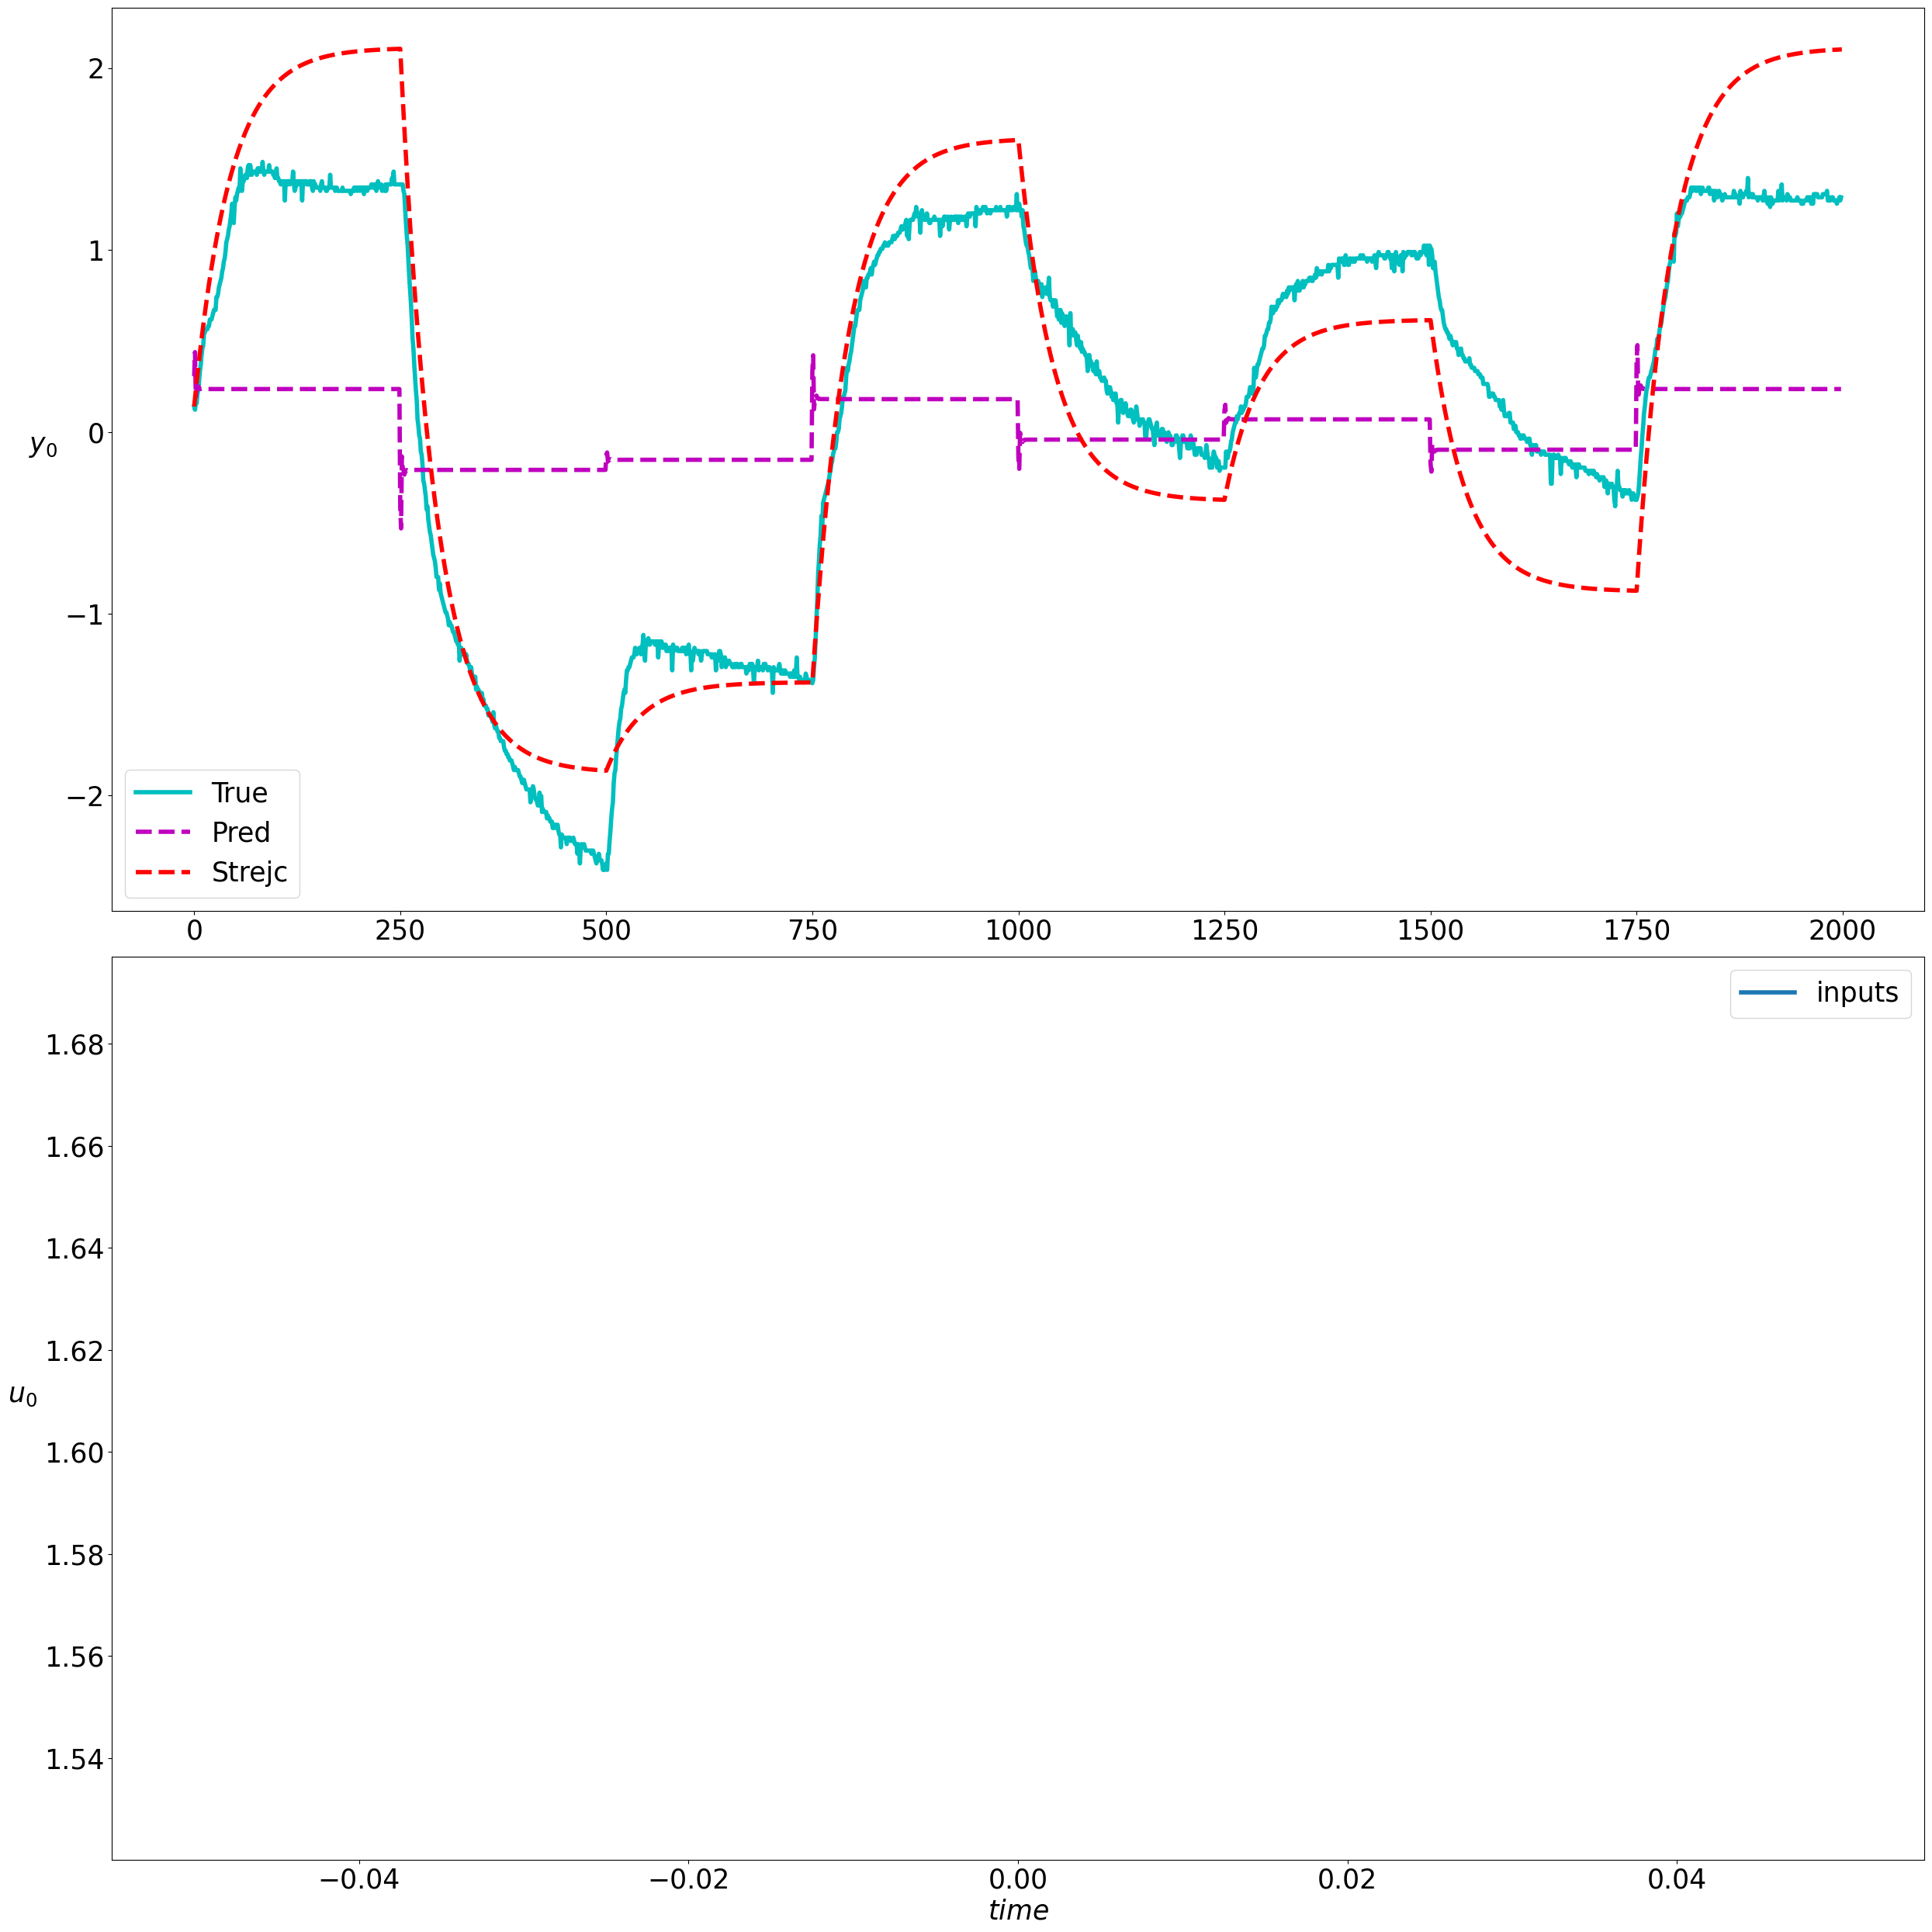

In [148]:
# plot trajectories
figsize = 25
fig, ax = plt.subplots(nx + nu, figsize=(figsize, figsize))
part = 2000

x_labels = [f'$y_{k}$' for k in range(len(true_traj))]
for row, (t1, t2, t3, t4, label) in enumerate(zip(true_traj, pred_traj, y_strejc.T, baseline_y, x_labels)):
    axe = ax[row]
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.plot(t1[:part], 'c', linewidth=4.0, label='True')
    axe.plot(t2[:part], 'm--', linewidth=4.0, label='Pred')
    axe.plot(t3[:part], 'r--', linewidth=4.0, label='Strejc')
    axe.tick_params(labelbottom=False, labelsize=figsize)
axe.tick_params(labelbottom=True, labelsize=figsize)
axe.legend(fontsize=figsize)

u_labels = [f'$u_{k}$' for k in range(1)]
for row, (u, label) in enumerate(zip(input_traj, u_labels)):
    axe = ax[1]# ax[row+nx]
    axe.plot(u[:part].T, linewidth=4.0, label='inputs')
    axe.legend(fontsize=figsize)
    axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
    axe.tick_params(labelbottom=True, labelsize=figsize)

ax[-1].set_xlabel('$time$', fontsize=figsize)
plt.tight_layout()

In [149]:
true_traj[0]

array([0.13969944, 0.12200621, 0.1573927 , ..., 1.2897602 , 1.272067  ,
       1.2897602 ], dtype=float32)

In [150]:
# part = 300
# jump = 10*part-part

# xs = scaler.inverse_transform([[0]])
# x0 = scaler.inverse_transform([true_traj[:,jump]])
# input_traj = scalerU.inverse_transform(test_data['U'][:,jump:jump+part].detach().numpy()[0])-50
# y_strejc = np.zeros((nx, part+1))
# y_strejc[:, 0] = x0-xs#x0
# for i in range(part):
#     y_strejc[:,i+1] = A_d @ y_strejc[:,i] + B_d @ input_traj[i]
# y_strejc = scaler.transform((y_strejc+xs).T)  


# # plot trajectories
# figsize = 25
# fig, ax = plt.subplots(nx + nu, figsize=(figsize, figsize))


# x_labels = [f'$y_{k}$' for k in range(len(true_traj))]
# for row, (t1, t2, t3, label) in enumerate(zip(true_traj, pred_traj, y_strejc.T, x_labels)):
#     axe = ax[row]
#     axe.set_ylabel(label, rotation=0, labelpad=20, fontsize=figsize)
#     axe.plot(t1[jump:jump+part], 'c', linewidth=4.0, label='True')
#     axe.plot(t2[jump:jump+part], 'm--', linewidth=4.0, label='Pred')
#     axe.plot(t3[:part], 'r--', linewidth=4.0, label='Strejc')
#     axe.tick_params(labelbottom=False, labelsize=figsize)
# axe.tick_params(labelbottom=True, labelsize=figsize)
# axe.legend(fontsize=figsize)



In [151]:
A = K.weight.detach().numpy()
B = f_u.weight.detach().numpy()
C = f_y_inv.weight.detach().numpy()
D = np.zeros((ny, nu))
""" 
np.save('./data/A_wC_all.npy', A)
np.save('./data/B_wC_all.npy', B)
np.save('./data/C_wC_all.npy', C)
np.save('./data/D_wC_all.npy', D) """


" \nnp.save('./data/A_wC_all.npy', A)\nnp.save('./data/B_wC_all.npy', B)\nnp.save('./data/C_wC_all.npy', C)\nnp.save('./data/D_wC_all.npy', D) "